In [1]:
import io
from datetime import datetime
import torch
import numpy as np
from model import *
import torch.optim as optim
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image


In [2]:
device = (
        "cuda"
        if torch.cuda.is_available()
        else "mps"
        if torch.backends.mps.is_available()
        else "xpu"
        if torch.xpu.is_available()
        else "cpu"
    )
print(f"Using {device} device")

Using cpu device


In [3]:
from YOLO_loader import get_classes

DIRECTORY = "face_dataset"

N_CELL = 52
IMG_SIZE = 416
N_ANCHORS = 3
TARGET_SIZE= (IMG_SIZE,IMG_SIZE)
N_CLASS = len(get_classes(DIRECTORY))
λ_coord = 5.0
λ_noobj = 0.5
λ_obj   = 1.0
λ_class = 1.0

answer = input("Do you want to load a model?(Yes/No)\n")
model = LightweightYOLO(num_classes=N_CLASS,num_anchors=N_ANCHORS,conv_layer=3, divider =1)
model = model.to(device) 
if answer == "Yes":
  nom = input("name of the file\n")
  model.load_state_dict(torch.load("model/"+nom))

loss_fn = YoloLoss(lambda_coord=5.0, lambda_noobj=0.5, lambda_obj=1.0)
optimizer = optim.Adam(model.parameters(),lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min')

test_loss =0.0
val_loss = 0.0

### Récupération des 3 ratios les plus probables ###

Traitement des labels:   0%|          | 0/12880 [00:00<?, ?it/s]

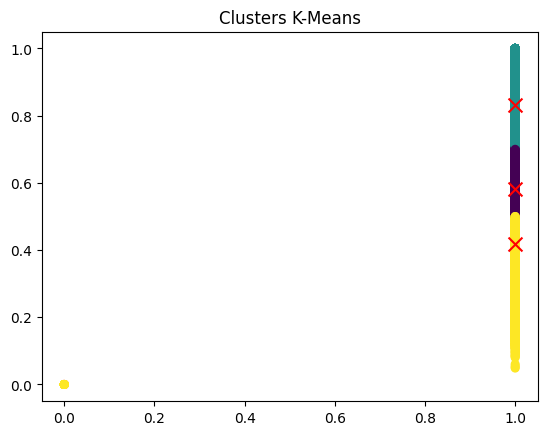

In [4]:
import numpy as np
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from YOLO_loader import get_labels
import time


labels = get_labels(DIRECTORY)
ratios = []
for label in tqdm(labels, desc="Traitement des labels", leave=True):
    boxes = label.get_bounding_boxes()
    for box in boxes :
        box_ratios = box.get_ratio()
        ratios.append(box_ratios)  
    time.sleep(0)
    
ratios = np.array(ratios)
k = 3
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(ratios)  

labels = kmeans.labels_
centers = kmeans.cluster_centers_


plt.scatter(ratios[:, 0], ratios[:, 1], c=labels, cmap='viridis', s=30)
plt.scatter(centers[:, 0], centers[:, 1], c='red', marker='x', s=100)
plt.title("Clusters K-Means")
plt.show()

In [5]:
from dataset import CardRecognitionDataset, custom_collate_fn
from torch.utils.data import Subset,DataLoader

dataset = CardRecognitionDataset(directory= DIRECTORY, n_cells=N_CELL,is_dark_and_white=False,target_size=TARGET_SIZE,bounding_boxes_ratio=centers)

STD = dataset.get_std()
MEAN = dataset.get_mean()

N = dataset.__len__()
train_size = int(0.7 * N)
val_size   = int(0.2 * N)   
indices = torch.randperm(N)
test_size  = N - train_size - val_size

train_indices = indices[:train_size]
val_indices   = indices[train_size:train_size+val_size]
test_indices  = indices[train_size+val_size:]


train_dataset = Subset(dataset, train_indices)
val_dataset   = Subset(dataset, val_indices)
test_dataset  = Subset(dataset, test_indices)


train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,collate_fn=custom_collate_fn)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False, collate_fn=custom_collate_fn)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False, collate_fn=custom_collate_fn)


c:\Programmation\object_recognition_tipe\.venv\Lib\site-packages\albumentations\core\validation.py:132: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
c:\Programmation\object_recognition_tipe\dataset.py:28: UserWarning: Argument(s) 'shift_limit' are not valid for transform OpticalDistortion
  Albu.OpticalDistortion(distort_limit=0.05, shift_limit=0.05, p=1),
c:\Programmation\object_recognition_tipe\dataset.py:30: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  Albu.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=1),
c:\Programmation\object_recognition_tipe\dataset.py:35: UserWarning: Argument(s) 'quality_lower, quality_upper' are not valid for transform ImageCompression
  Albu.ImageCompression(quality_lower=85, quality_upper=95, p=1),
c:\Programmation\object_recognition_tipe\dataset.py:57: UserWarning: Argument(s) 'num_shadows_lower, num_sha

Traitement des labels:   0%|          | 0/3832 [00:00<?, ?it/s]

i cell :  15 j cell : 25
i cell :  9 j cell : 24
i cell :  18 j cell : 10
i cell :  18 j cell : 14
i cell :  13 j cell : 19
i cell :  13 j cell : 25
i cell :  10 j cell : 33
i cell :  12 j cell : 39
i cell :  18 j cell : 22
i cell :  24 j cell : 32
i cell :  12 j cell : 18
i cell :  9 j cell : 28
i cell :  29 j cell : 6
i cell :  14 j cell : 6
i cell :  19 j cell : 20
i cell :  11 j cell : 30
i cell :  18 j cell : 38
i cell :  19 j cell : 44
i cell :  16 j cell : 12
i cell :  31 j cell : 14
i cell :  8 j cell : 32
i cell :  14 j cell : 36
i cell :  27 j cell : 47
i cell :  5 j cell : 20
i cell :  15 j cell : 28
i cell :  36 j cell : 46
i cell :  41 j cell : 25
i cell :  42 j cell : 28
i cell :  24 j cell : 26
i cell :  23 j cell : 36
i cell :  38 j cell : 33
i cell :  40 j cell : 39
i cell :  37 j cell : 38
i cell :  42 j cell : 33
i cell :  44 j cell : 33
i cell :  42 j cell : 38
i cell :  46 j cell : 35
i cell :  42 j cell : 44
i cell :  42 j cell : 45
i cell :  41 j cell : 49
i cell

IndexError: index 53 is out of bounds for dimension 2 with size 52

In [ ]:
from YOLO_loader import BoundingBox
import math

torch.set_printoptions(threshold=float('inf'))

def run_one_epoch(loader:DataLoader, train=True):
    model.train(train)
    running_loss = 0.0
    preds, targets = [], []

    for custom_imgs, images, labels in loader:
        inputs = images.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.float32)



        if train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train):
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)


            if train:
                loss.backward()
                optimizer.step()
                if scheduler is not None and isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR):
                    scheduler.step()

            copied_labels = torch.clone(labels).detach().cpu()
            copied_outputs = torch.clone(outputs).detach().cpu()
            images = []
            for i in range(len(custom_imgs)):
                custom_img = custom_imgs[i]
                W, H = custom_img.target_size
                output_bb_boxes = []
                for bb_box in custom_img.get_bounding_boxes():
                    position = bb_box.get_cell_position(custom_img.grid_division)

                    anchor_index = bb_box.get_bounding_box_index(centers)
                    x,y = position
                    output_bb_boxes.append([BoundingBox.from_tensor(copied_outputs[i,int(x),int(y),a,:],N_CLASS,int(x),int(y),N_CELL) for a in range(3)])
                output_bb_boxes = np.array(output_bb_boxes, dtype=object).flatten()
                images.append(custom_img.get_image(output_bb_boxes))

            images_np = np.array(images)  # (B,H,W,C)
            batch_size = images_np.shape[0]
            grid_size = math.ceil(math.sqrt(batch_size))  # Taille de la grille

            fig, axes = plt.subplots(grid_size, grid_size, figsize=(4*grid_size, 4*grid_size))
            axes = axes.flatten()  # Pour itérer facilement même si c'est 2D

            for i in range(batch_size):
                axes[i].imshow(images_np[i])
                axes[i].axis('off')

            # Masquer les axes vides si batch_size < grid_size**2
            for i in range(batch_size, grid_size**2):
                axes[i].axis('off')

            plt.tight_layout()
            plt.show()
        running_loss += loss.item()

        if not train:
            preds.append(outputs.detach().cpu())
            targets.append(labels.detach().cpu())

    epoch_loss = running_loss / len(loader)

    if train and scheduler is not None and not isinstance(scheduler, torch.optim.lr_scheduler.OneCycleLR):
        scheduler.step(epoch_loss)

    if train:
        return epoch_loss
    else:
        return torch.cat(preds), torch.cat(targets), epoch_loss


In [ ]:
num_epochs = 50
model.train(True)
for epoch in range(num_epochs):
    loss = run_one_epoch(train_loader, True)
    #preds, targets, val_loss = run_one_epoch(val_loader, train=False)
    print(f"Epoch {epoch} loss: {loss} (type: {type(loss)})")

preds, targets, val_loss = run_one_epoch(val_loader, train=False)
print(f"Epoch {epoch} loss: {loss} (type: {type(loss)})")

In [ ]:
torch.save(model.state_dict(), 'model/version6.pth')